# Airport Network Analysis — Geographic Visualisation

This notebook maps airport locations and highlights the geographical distribution of global hubs.

## Objective

The objective of this notebook is to examine the geographical distribution of airports in the global air transportation network.

Specifically, this notebook investigates:

- The worldwide spatial distribution of airports.
- The geographic concentration of major hub airports.
- The relationship between airport location and network connectivity.
- A spatial visualization of the complete airport transportation network.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph

G = build_graph('../Data')

## 1. Airport locations

Longitude and latitude coordinates make it possible to inspect the spatial coverage of the network without relying on an external map service.

In [2]:
airport_map = pd.DataFrame([
    {
        'airport_id': node, 'name': data['name'], 'country': data['country'],
        'latitude': data['latitude'], 'longitude': data['longitude'], 'degree': G.degree(node)
    }
    for node, data in G.nodes(data=True)
])
airport_map[['latitude', 'longitude']] = airport_map[['latitude', 'longitude']].apply(pd.to_numeric, errors='coerce')
airport_map = airport_map.dropna(subset=['latitude', 'longitude'])
airport_map.head()

,airport_id,name,country,latitude,longitude,degree
0,1,Goroka Airport,Papua New Guinea,-6.081690,145.391998,8
1,2,Madang Airport,Papua New Guinea,-5.207080,145.789001,14
2,3,Mount Hagen Kagamuga Airport,Papua New Guinea,-5.826790,144.296005,17
3,4,Nadzab Airport,Papua New Guinea,-6.569803,146.725977,18
4,5,Port Moresby Jacksons International Airport,Papua New Guinea,-9.443380,147.220001,64


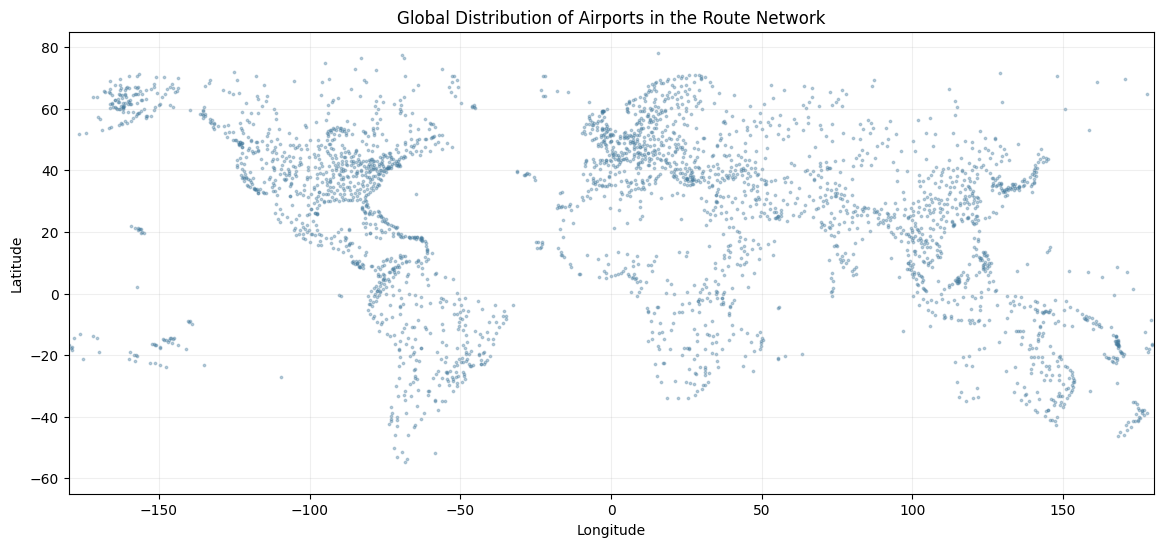

In [3]:
plt.figure(figsize=(14, 6))
plt.scatter(airport_map['longitude'], airport_map['latitude'], s=3, alpha=0.35, color='#457b9d')
plt.xlim(-180, 180)
plt.ylim(-65, 85)
plt.grid(alpha=0.2)
plt.title('Global Distribution of Airports in the Route Network')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Interpretation

The airport network spans every populated continent, demonstrating the global reach of modern air transportation.

However, the spatial distribution of airports is not uniform. High airport density is observed in North America, Europe, and East Asia, whereas Africa, parts of South America, and Oceania contain comparatively fewer airports.

This uneven geographical distribution reflects differences in population density, economic activity, and the development of regional aviation infrastructure.

## 2. Geographic distribution of hub airports

Marker size reflects total degree. Labels are shown only for the top 20 hubs so the figure remains readable.

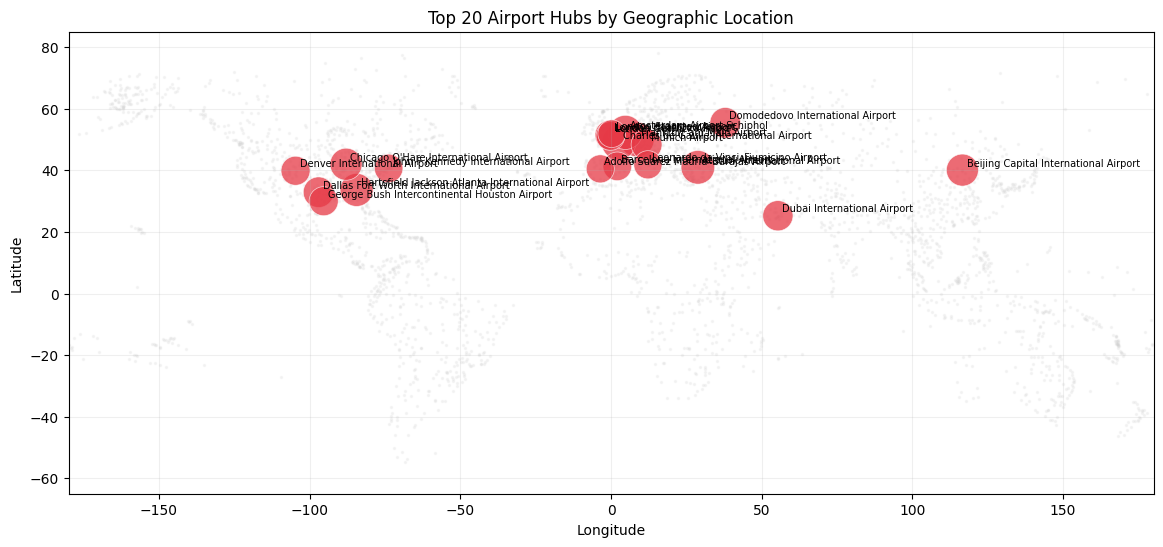

In [4]:
top_hubs = airport_map.nlargest(20, 'degree')

plt.figure(figsize=(14, 6))
plt.scatter(airport_map['longitude'], airport_map['latitude'], s=2, alpha=0.18, color='lightgray')
plt.scatter(top_hubs['longitude'], top_hubs['latitude'], s=top_hubs['degree'] * 1.3,
            alpha=0.75, color='#e63946', edgecolor='white', linewidth=0.5)
for _, airport in top_hubs.iterrows():
    plt.annotate(airport['name'], (airport['longitude'], airport['latitude']),
                 xytext=(3, 3), textcoords='offset points', fontsize=7)
plt.xlim(-180, 180)
plt.ylim(-65, 85)
plt.grid(alpha=0.2)
plt.title('Top 20 Airport Hubs by Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Interpretation

The largest hub airports are concentrated in economically developed and densely connected regions, particularly North America, Europe, East Asia, and the Middle East.

This concentration reflects the hub-and-spoke structure of the global aviation network, where a relatively small number of strategically located airports serve as major transfer points connecting thousands of origin–destination pairs.

The geographic clustering of these hubs also explains why targeted failures at a few critical airports can significantly disrupt worldwide connectivity, as demonstrated in the resilience analysis.

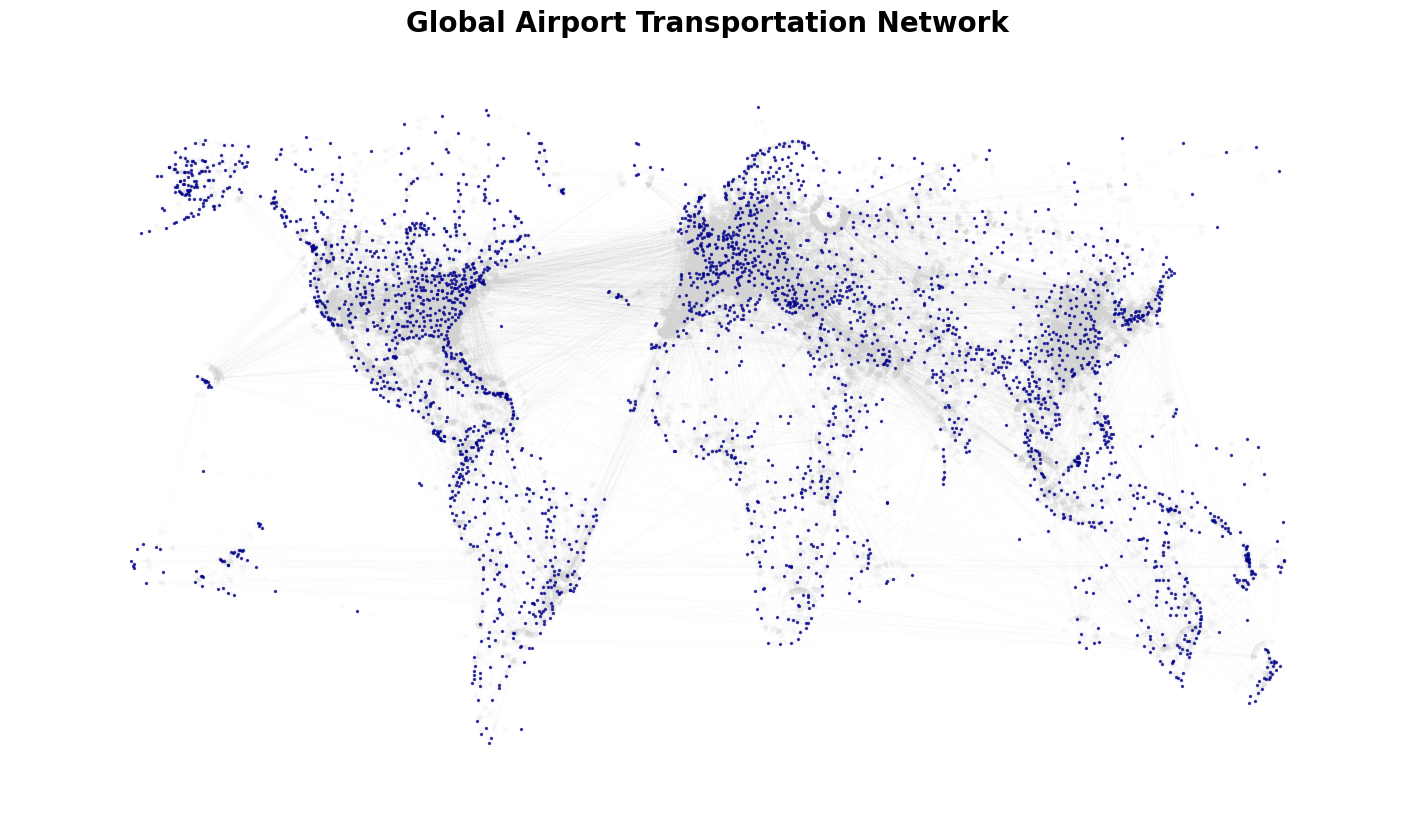

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(18, 10))

pos = {
    node: (
        G.nodes[node]["longitude"],
        G.nodes[node]["latitude"]
    )
    for node in G.nodes()
}

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="lightgray",
    alpha=0.08,
    width=0.2
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2,
    node_color="darkblue",
    alpha=0.7
)

plt.title(
    "Global Airport Transportation Network",
    fontsize=20,
    weight="bold"
)

plt.axis("off")

plt.savefig(
    "../Reports/figures/global_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

This notebook demonstrates that the global airport network exhibits a highly uneven geographical structure.

Although airports are distributed across every populated continent, the most influential hubs are concentrated within a relatively small number of economically developed regions. These hubs serve as major transfer points that connect geographically distant parts of the world and enable efficient global air transportation.

The spatial distribution observed in this notebook provides geographical evidence for the network characteristics identified in the centrality and resilience analyses. Together, these results show that both the location and the structural importance of airports must be considered when assessing the robustness of the worldwide aviation network.